In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
def phi1(t, j):
    return t**(j - 1)

In [27]:
def phi2(t, j):
    return (t - 1990)**(j - 1)

In [28]:
def phi3(t, j):
    return (t - 1940)**(j - 1)

In [29]:
def phi4(t, j):
    return ((t - 1940) / 40)**(j - 1)

In [30]:
file = pd.read_csv("./USA_population.csv", delimiter=';').dropna()

In [31]:
years = np.astype(file.Rok.values, np.float64)
populations = file.Populacja.values

# a

In [32]:
j_s = np.array([i for i in range(1, 10)])
years_column = years[:, np.newaxis]
functions = [phi1, phi2, phi3, phi4]

vandermonds_matrixes = [fun(years_column, j_s) for fun in functions]

In [33]:
print(vandermonds_matrixes)

[array([[1.00000000e+00, 1.90000000e+03, 3.61000000e+06, 6.85900000e+09,
        1.30321000e+13, 2.47609900e+16, 4.70458810e+19, 8.93871739e+22,
        1.69835630e+26],
       [1.00000000e+00, 1.91000000e+03, 3.64810000e+06, 6.96787100e+09,
        1.33086336e+13, 2.54194902e+16, 4.85512263e+19, 9.27328422e+22,
        1.77119729e+26],
       [1.00000000e+00, 1.92000000e+03, 3.68640000e+06, 7.07788800e+09,
        1.35895450e+13, 2.60919263e+16, 5.00964985e+19, 9.61852772e+22,
        1.84675732e+26],
       [1.00000000e+00, 1.93000000e+03, 3.72490000e+06, 7.18905700e+09,
        1.38748800e+13, 2.67785184e+16, 5.16825405e+19, 9.97473033e+22,
        1.92512295e+26],
       [1.00000000e+00, 1.94000000e+03, 3.76360000e+06, 7.30138400e+09,
        1.41646850e+13, 2.74794888e+16, 5.33102083e+19, 1.03421804e+23,
        2.00638300e+26],
       [1.00000000e+00, 1.95000000e+03, 3.80250000e+06, 7.41487500e+09,
        1.44590062e+13, 2.81950622e+16, 5.49803713e+19, 1.07211724e+23,
        2.

# b

In [34]:
conds = np.linalg.cond(vandermonds_matrixes)

In [35]:
print(conds)

[7.96584873e+36 8.08579400e+16 9.31553604e+12 1.60544370e+03]


# c

In [36]:
best_conditioned_polynomial_basis = vandermonds_matrixes[3]
coefficients = np.linalg.solve(best_conditioned_polynomial_basis, populations)

In [37]:
print(coefficients)

[ 1.32164569e+08  4.61307656e+07  1.02716315e+08  1.82527130e+08
 -3.74614715e+08 -3.42668456e+08  6.06291250e+08  1.89175576e+08
 -3.15180235e+08]


In [38]:
def horner(coefficients, x):
    reversed_coefficients = coefficients[::-1]
    result = reversed_coefficients[0]

    for a in reversed_coefficients[1::]:
        result = result * x + a
        
    return result

In [39]:
all_years = np.arange(1900, 1991)
all_years_normalized = (all_years - 1940) / 40
values_horner = horner(coefficients, all_years_normalized)
#print(values_horner[:5])
#print(np.polyval(coefficients[::-1],all_years)[:5])

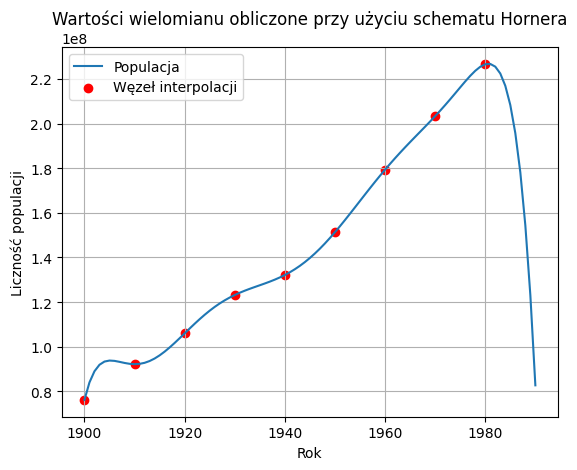

In [63]:
plt.plot(all_years, values_horner, label="Populacja")
plt.scatter(years,populations,color="red",label="Węzeł interpolacji")
plt.title("Wartości wielomianu obliczone przy użyciu schematu Hornera")
plt.xlabel("Rok")
plt.ylabel("Liczność populacji")
plt.grid(True)
plt.legend()

# d

In [41]:
estimated_value = values_horner[-1]
true_value = 248_709_873
relative_error = abs(estimated_value - true_value) / true_value
print(relative_error)

0.6672864651416608


# e

In [42]:
def create_lagrange_polynomial(nodes):
    result_functions = []

    for j in range(len(nodes)):
        l_j = lambda x, j_idx=j, all_nodes=nodes: np.prod([
            (x - n) / (all_nodes[j_idx] - n)
            for k, n in enumerate(all_nodes) if k != j_idx
        ],axis=0)
        result_functions.append(l_j)

    return result_functions


In [43]:
unique_polynomials = create_lagrange_polynomial(years)
lagrange_poly = lambda x: sum(y * L(x) for y, L in zip(populations, unique_polynomials))
values_lagrange = lagrange_poly(all_years)

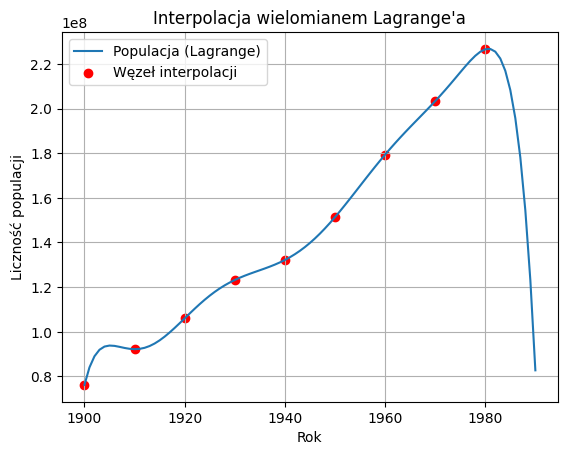

In [50]:
plt.clf()
plt.plot(all_years, values_lagrange, label="Populacja (Lagrange)")
plt.scatter(years,populations,color="red",label="Węzeł interpolacji")
plt.title("Interpolacja wielomianem Lagrange'a")
plt.xlabel("Rok")
plt.ylabel("Liczność populacji")
plt.grid(True)
plt.legend()

# f

In [45]:
def newton_divided_differences(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:, 0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :]

In [ ]:

def evaluate_newton_poly(coef, x_nodes, x_eval):
    n = len(coef)
    p = coef[n-1]
    for k in range(1, n):
        p = coef[n-1-k] + (x_eval - x_nodes[n-1-k]) * p
    return p

In [51]:
newton_coefs = newton_divided_differences(years, populations)

values_newton = evaluate_newton_poly(newton_coefs, years, all_years)

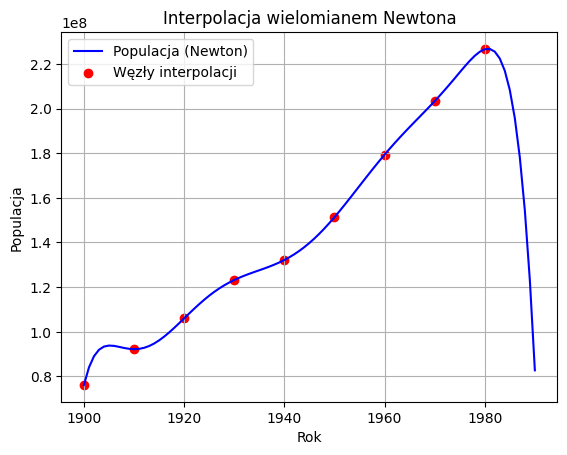

In [ ]:
plt.clf()
plt.plot(all_years, values_newton, label="Populacja (Newton)", linestyle='-', color='blue')
plt.scatter(years, populations, color='red', marker='o', label="Węzły interpolacji")
plt.title("Interpolacja wielomianem Newtona")
plt.xlabel("Rok")
plt.ylabel("Liczność opulacja")
plt.legend()
plt.grid(True)
plt.show()

# g

In [57]:
populations_rounded = np.round(np.array(populations), -6) 

# matrix from (c)
coefficients_rounded = np.linalg.solve(vandermonds_matrixes[3], populations_rounded)

In [58]:
print("Współczynniki oryginalne z (c):")
print(coefficients)
print("\nWspółczynniki po zaokrągleniu z (g):")
print(coefficients_rounded)
print("\nBezwzględna różnica między współczynnikami:")
print(np.abs(coefficients - coefficients_rounded))

Współczynniki oryginalne z (c):
[ 1.32164569e+08  4.61307656e+07  1.02716315e+08  1.82527130e+08
 -3.74614715e+08 -3.42668456e+08  6.06291250e+08  1.89175576e+08
 -3.15180235e+08]

Współczynniki po zaokrągleniu z (g):
[ 1.32000000e+08  4.59571429e+07  1.00141270e+08  1.81111111e+08
 -3.56755556e+08 -3.38488889e+08  5.70311111e+08  1.86920635e+08
 -2.94196825e+08]

Bezwzględna różnica między współczynnikami:
[  164569.           173622.71904767  2575044.94444448  1416019.06666672
 17859159.33333337  4179566.93333346 35980138.66666675  2254940.64761907
 20983409.77777785]


In [59]:
values_horner_rounded = horner(coefficients_rounded, all_years_normalized)

pop_1990_extrapolated = values_horner_rounded[-1] 

true_pop_1990 = 248_709_873

relative_error = np.abs(true_pop_1990 - pop_1990_extrapolated) / np.abs(true_pop_1990)

In [60]:
print(f"\nEkstrapolowana populacja na 1990: {pop_1990_extrapolated:.2f}")
print(f"Prawdziwa populacja w 1990: {true_pop_1990}")
print(f"Błąd względny ekstrapolacji: {relative_error * 100:.2f}%")


Ekstrapolowana populacja na 1990: 109000000.00
Prawdziwa populacja w 1990: 248709873
Błąd względny ekstrapolacji: 56.17%


<Figure size 640x480 with 0 Axes>

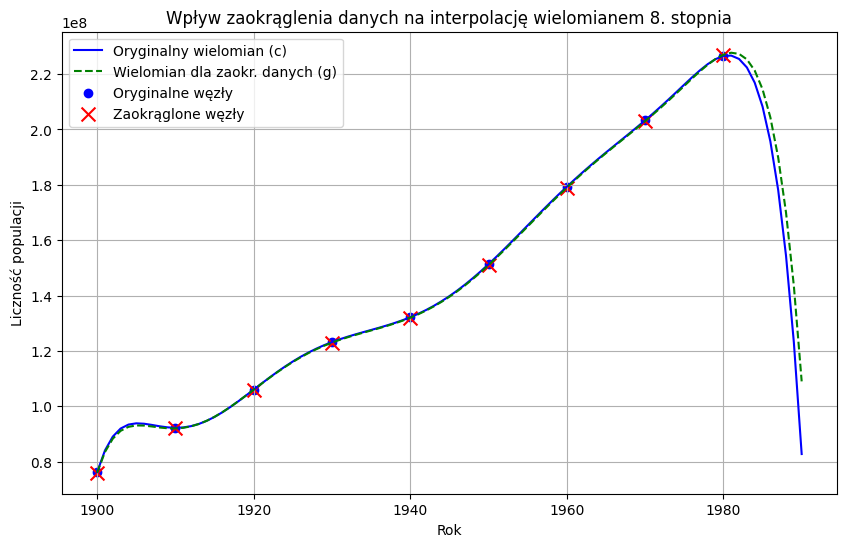

In [61]:

plt.clf()
plt.figure(figsize=(10, 6))
plt.plot(all_years, values_horner, label="Oryginalny wielomian (c)", color="blue")
plt.plot(all_years, values_horner_rounded, label="Wielomian dla zaokr. danych (g)", color="green", linestyle="--")
plt.scatter(years, populations, color="blue", label="Oryginalne węzły")
plt.scatter(years, populations_rounded, color="red", marker="x", s=100, label="Zaokrąglone węzły")
plt.title("Wpływ zaokrąglenia danych na interpolację wielomianem 8. stopnia")
plt.xlabel("Rok")
plt.ylabel("Liczność populacji")
plt.legend()
plt.grid(True)
plt.show()